In [336]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hesh97/titanicdataset-traincsv/train.csv


# Mathematical Transformations

At its core, a mathematical transformation is simply taking an input value, passing it through a specific mathematical formula, and getting a new output value.

**Its types are:**

1. log transform
2. reciprocal
3. power (sq/sqrt)
4. box-cox
5. yeo-johnson

The end goal of all these transformations is to convert the given data into a nomally distributed function

**Sklearn has three parts:**
1. Function Transformer
   * Power(sq/sqrt)
   * log
   * reciprocal
   * custon funtion
2. Power Tranformer
   * box-cox
   * yeo-johnson
3. Quantile Transformer

# How do I find if the data is normally distributed?
1. sns.distplot
2. pd.skew() - if 0 it means it is properly balanced
3. QQ plot

# Log Transform
**How to use?**

apply log on all items.

**When to use?**

When the data is right skewed.

**How does it help?**

It equifies the distance between all the points.

# Square Transform
**When to use?**

it is left skewed

In [337]:
import numpy as np
import pandas as pd

import scipy.stats as stats #QQ plot

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [338]:
df = pd.read_csv('/kaggle/input/datasets/hesh97/titanicdataset-traincsv/train.csv', usecols=['Age', 'Fare', 'Survived'])

In [339]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [340]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [341]:
df['Age'] = df['Age'].fillna(df['Age'].mean()).infer_objects(copy=False)

In [342]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [343]:
X = df.iloc[:, 1:3]
y = df.iloc[:, 0]

In [344]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

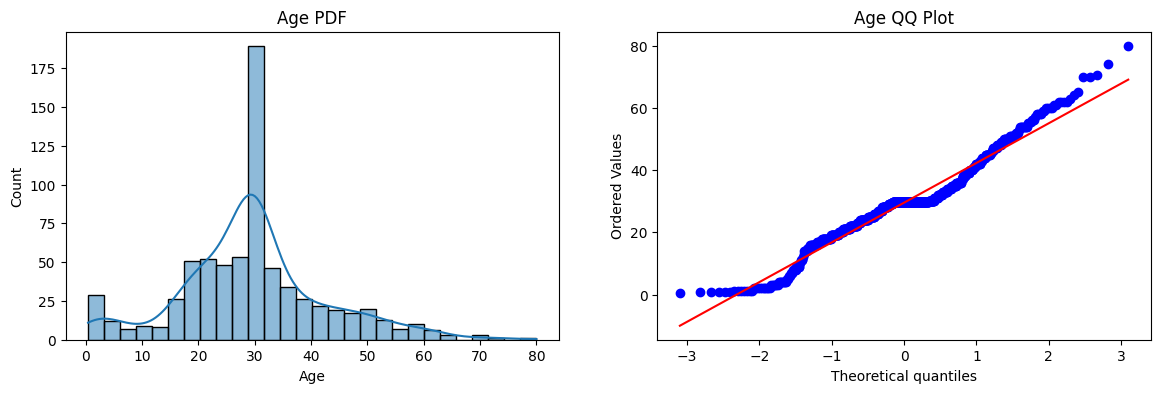

In [345]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Age'], kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Age QQ Plot')

plt.show()

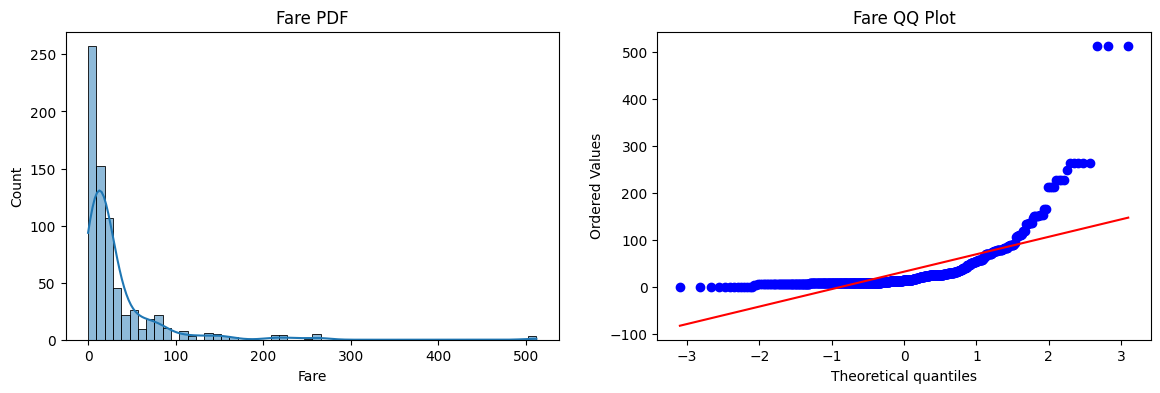

In [346]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Fare'], kde=True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [347]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [348]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Accuracy LR: ", accuracy_score(y_test, y_pred)*100)
print("Accuracy DT: ", accuracy_score(y_test, y_pred1)*100)

Accuracy LR:  64.80446927374301
Accuracy DT:  65.36312849162012


In [349]:
trf = FunctionTransformer(func=np.log1p)

In [350]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.fit_transform(X_test)

In [351]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

print("Accuracy LR: ", accuracy_score(y_test, y_pred)*100)
print("Accuracy DT: ", accuracy_score(y_test, y_pred1)*100)

Accuracy LR:  68.15642458100558
Accuracy DT:  67.59776536312849


In [352]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('LR', np.mean(cross_val_score(clf, X_transformed, y, scoring='accuracy', cv=10))*100)
print('DT', np.mean(cross_val_score(clf2, X_transformed, y, scoring='accuracy', cv=10))*100)

LR 67.80274656679151
DT 65.8876404494382


Text(0.5, 1.0, 'Age after Log')

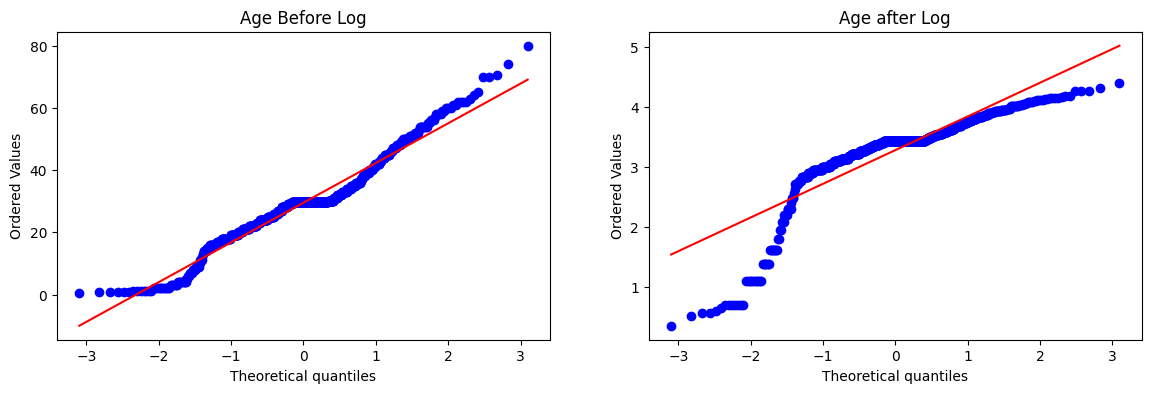

In [353]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist='norm', plot=plt)
plt.title('Age after Log')

Text(0.5, 1.0, 'Fare after Log')

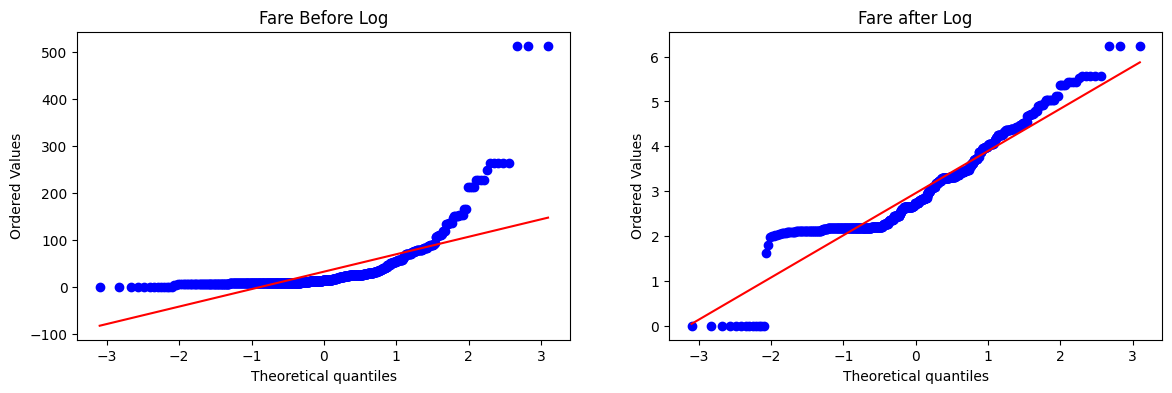

In [354]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist='norm', plot=plt)
plt.title('Fare after Log')

In [355]:
trf2 = ColumnTransformer([('log', FunctionTransformer(np.log1p), ['Fare'])], remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.fit_transform(X_test)

In [356]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2, y_train)
clf2.fit(X_train_transformed2, y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf.predict(X_test_transformed2)

print('Accuracy LR', accuracy_score(y_test, y_pred)*100)
print('Accuracy DT', accuracy_score(y_test, y_pred2)*100)

Accuracy LR 67.0391061452514
Accuracy DT 67.0391061452514


In [357]:
def apply_transform(transform):
    X = df.iloc[:, 1:3]
    y = df.iloc[:, 0]
    trf = ColumnTransformer([('log', FunctionTransformer(transform), ['Fare'])], remainder='passthrough')
    X_trans = trf.fit_transform(X)
    clf = LogisticRegression()
    print("Accuracy", np.mean(cross_val_score(clf, X_trans, y, scoring='accuracy', cv=10))*100)
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    stats.probplot(X['Fare'], dist='norm', plot=plt)
    plt.title('Fare Before Transform')
    plt.subplot(122)
    stats.probplot(X_trans[:, 0], dist='norm', plot=plt)
    plt.title('Fare After Transform')
    plt.show()

Accuracy 65.89013732833958


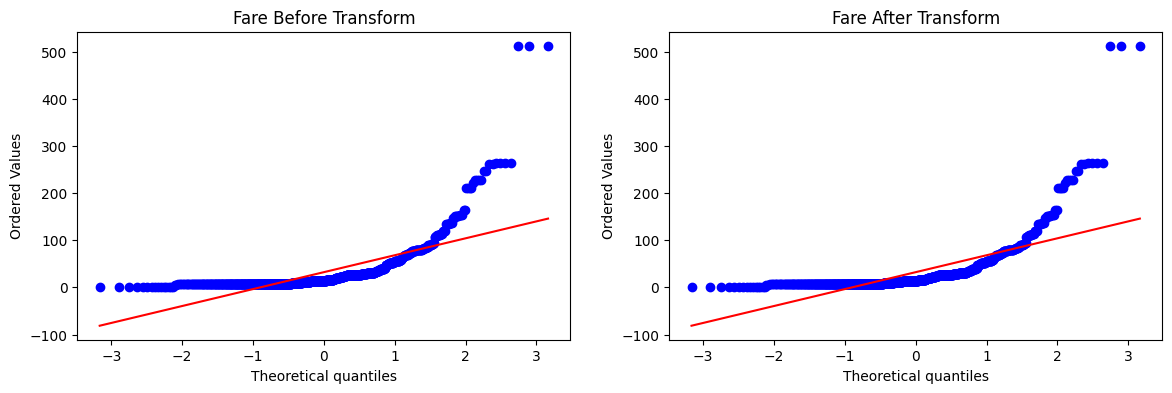

In [362]:
apply_transform(lambda x:x)